# 02 — CA Gubernatorial Race 2026: Donation Distribution & OpenSecrets Matching

This notebook visualises the distribution of campaign contributions in the 2026 CA Governor's race and matches individual donors against the OpenSecrets contribution database.

**Three donor categories** (per CalAccess/FPPC logic):
| Donor Type | Rule |
|---|---|
| **Individual** | Has a `Contributor Occupation` entry |
| **Organization** | No Contributor ID AND no Contributor Occupation |
| **PAC / Committee** | Has a `Contributor ID` |

**Four individual spending tiers** (based on CA FPPC individual contribution limits):
| Tier | Range |
|---|---|
| High Spender | ≥ $36,400 (FPPC statewide limit) |
| Medium Spender | $10,000 – $36,400 |
| Lower Spender | $200 – $10,000 |
| Everyday | < $200 |

---


In [1]:
from __future__ import annotations
import re, textwrap, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# ── Paths ──────────────────────────────────────────────────────────────────────
# Adjust if needed. BASE_DIR is the root of this project folder.
BASE_DIR        = Path("..").resolve()          # one level up from code/
DATA_DIR        = BASE_DIR / "data"
GOV_RACE_PATH   = DATA_DIR / "01CalAccess_CampaignFinance_Data" / "governor_race_2026-03-20.csv"
OPENSECRETS_PATH = DATA_DIR / "ContributionOpenSecretsCategories (1).csv"

OUTPUT_DIR = DATA_DIR / "02_output"
FIG_DIR    = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────────
CA_INDIVIDUAL_LIMIT = 36_400   # FPPC 2025-26 statewide race individual limit

BUCKET_LIMITS = {
    "Everyday (<$200)":     (0,       200),
    "Lower ($200-$10K)":    (200,   10_000),
    "Medium ($10K-limit)":  (10_000, CA_INDIVIDUAL_LIMIT),
    "High (≥ limit)":       (CA_INDIVIDUAL_LIMIT, float("inf")),
}
BUCKET_ORDER   = list(BUCKET_LIMITS.keys())
BUCKET_COLORS  = ["#74B9E1", "#55A868", "#E8A838", "#C44E52"]

DONOR_COLORS = {
    "Individual":    "#4C72B0",
    "Organization":  "#55A868",
    "PAC/Committee": "#C44E52",
}

print("Paths configured. Data directory:", DATA_DIR)


Paths configured. Data directory: /Users/kateli/Desktop/CalMatters/campaign finance categorization/data


In [2]:
# ── Helper utilities ───────────────────────────────────────────────────────────

def clean_amount(series: pd.Series) -> pd.Series:
    """Strip dollar signs / commas and coerce to float."""
    s = series.astype(str).str.replace(r"[$,]", "", regex=True).str.strip()
    return pd.to_numeric(s, errors="coerce")


def detect_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Return the first candidate column name that exists (case-insensitive)."""
    low = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in low:
            return low[c.lower()]
    return None


def normalise_name(name: str) -> str:
    """Upper-case, strip punctuation, collapse whitespace for matching."""
    if not isinstance(name, str):
        return ""
    n = re.sub(r"[^A-Z0-9 ]", " ", name.upper())
    return re.sub(r"\s+", " ", n).strip()


## 1. Load Data & Classify Donor Types

In [3]:
df = pd.read_csv(GOV_RACE_PATH, dtype=str, low_memory=False)
print(f"{len(df):,} rows × {df.shape[1]} columns (raw)")

# Drop exact-duplicate rows. The CalAccess export contains byte-for-byte
# identical records (same transaction reported multiple times) — most visible
# at the FPPC limit, where contributors appear at exactly 2× the cap (e.g.
# Safai, Bob shows two identical $39,200 rows = $78,400).
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df):,} exact duplicate rows → {len(df):,} unique rows")
print("Columns:", list(df.columns))


89,609 rows × 22 columns (raw)
Dropped 2,269 exact duplicate rows → 87,340 unique rows
Columns: ['Transaction Type', 'Cycle', 'Election', 'Start Date', 'End Date', 'Amount', 'Recipient Name', 'Recipient Committee', 'Recipient Committee ID', 'Office', 'District', 'Ballot Measure(s)', 'Contributor Name', 'Contributor ID', 'Contributor City', 'Contributor State', 'Contributor Zip Code', 'Contributor Employer', 'Contributor Occupation', 'Candidate Contribution', 'Ballot Measure Contribution', 'Allied Committee']


In [4]:
# ── Locate key columns ────────────────────────────────────────────────────────
col_name = detect_col(df, ["Contributor Name", "CTRIB_NAML", "contributor_name"])
col_occ  = detect_col(df, ["Contributor Occupation", "CTRIB_OCC"])
col_id   = detect_col(df, ["Contributor ID", "CMTE_ID", "FILER_ID", "Committee ID"])
col_amt  = detect_col(df, ["Amount", "AMOUNT", "TRAN_AMT1"])

print(f"Name col   : {col_name}")
print(f"Occupation : {col_occ}")
print(f"ID col     : {col_id}")
print(f"Amount col : {col_amt}")


Name col   : Contributor Name
Occupation : Contributor Occupation
ID col     : Contributor ID
Amount col : Amount


In [5]:
# ── Classify each row as Individual / Organization / PAC/Committee ────────────
df["amount_clean"] = clean_amount(df[col_amt])

# Boolean masks
has_occ = (
    df[col_occ].notna()
    & df[col_occ].str.strip().ne("")
    & df[col_occ].str.lower().ne("nan")
) if col_occ else pd.Series(False, index=df.index)

has_id = (
    df[col_id].notna()
    & df[col_id].str.strip().ne("")
    & df[col_id].str.lower().ne("nan")
) if col_id else pd.Series(False, index=df.index)

df["donor_type"] = np.select(
    [has_id, has_occ],
    ["PAC/Committee", "Individual"],
    default="Organization",
)

# Convenience columns
df["_name"] = df[col_name].fillna("").str.strip()
df["_occ"]  = df[col_occ].fillna("").str.strip() if col_occ else ""

# Summary
counts = df["donor_type"].value_counts()
pcts   = counts / len(df) * 100
summary = pd.DataFrame({"Count": counts, "Pct (%)": pcts.round(2)})
print("\nDonor type breakdown:\n")
display(summary)



Donor type breakdown:



,Count,Pct (%)
donor_type,,
Individual,85038,97.36
Organization,2019,2.31
PAC/Committee,283,0.32


## 2. Distribution of Donation Amounts by Donor Type

Each panel below shows the **histogram of donation sizes** for one donor type,
with a log-scaled x-axis so we can see both tiny ($1) and very large ($36K+) donations
in the same view. The dashed line marks the **median**.


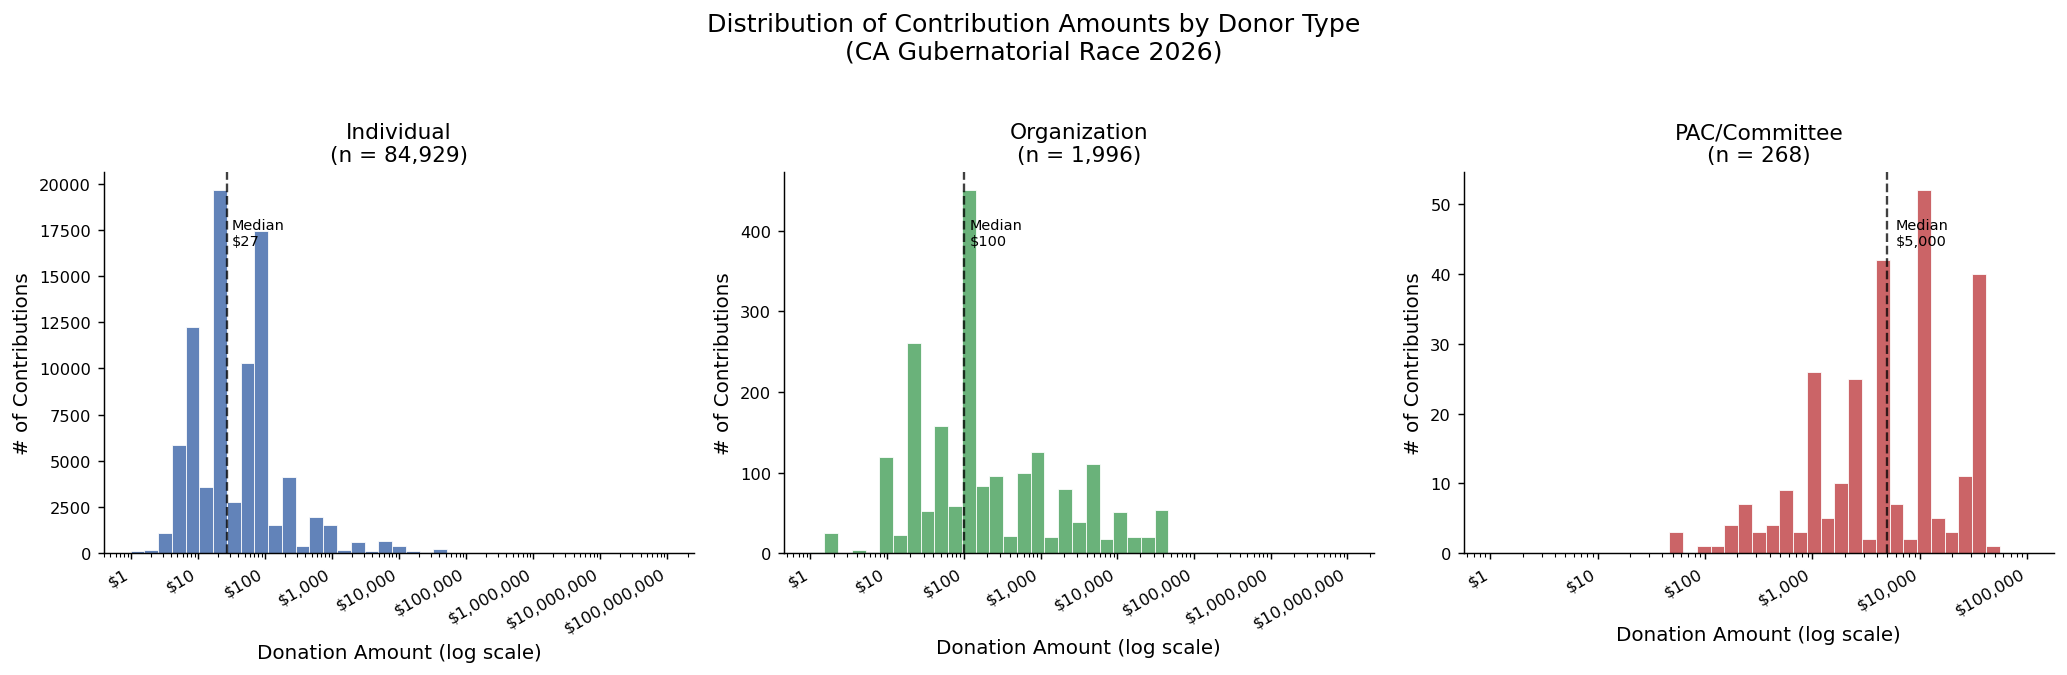

Saved: 01_donation_distributions.png


In [6]:
donor_types = ["Individual", "Organization", "PAC/Committee"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Distribution of Contribution Amounts by Donor Type\n(CA Gubernatorial Race 2026)",
    fontsize=14, y=1.03,
)

for ax, dt in zip(axes, donor_types):
    sub = df.loc[df["donor_type"] == dt, "amount_clean"].dropna()
    sub = sub[sub > 0]

    if sub.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(dt)
        continue

    log_min = max(0, np.floor(np.log10(sub.min())))
    log_max = np.ceil(np.log10(sub.max()))
    bins = np.logspace(log_min, log_max, 40)

    ax.hist(sub, bins=bins, color=DONOR_COLORS[dt], edgecolor="white",
            linewidth=0.5, alpha=0.88)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}" if x >= 1 else f"${x:.2f}")
    )

    # Median line
    med = sub.median()
    ax.axvline(med, color="black", linestyle="--", linewidth=1.3, alpha=0.75)
    ax.text(
        med * 1.2, ax.get_ylim()[1] * 0.88,
        f"Median\n${med:,.0f}", fontsize=8, color="black", va="top",
    )

    ax.set_title(f"{dt}\n(n = {len(sub):,})", fontsize=12)
    ax.set_xlabel("Donation Amount (log scale)")
    ax.set_ylabel("# of Contributions")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
fig.savefig(FIG_DIR / "01_donation_distributions.png", bbox_inches="tight")
plt.show()
print("Saved: 01_donation_distributions.png")


In [7]:
# Key statistics per donor type
stats_rows = []
for dt in donor_types:
    sub = df.loc[df["donor_type"] == dt, "amount_clean"].dropna()
    sub_pos = sub[sub > 0]
    stats_rows.append({
        "Donor Type":     dt,
        "# Contributions": f"{len(sub):,}",
        "Total ($)":       f"${sub.sum():,.0f}",
        "Mean ($)":        f"${sub.mean():,.0f}",
        "Median ($)":      f"${sub.median():,.0f}",
        "Max ($)":         f"${sub.max():,.0f}",
        "Min ($)":         f"${sub_pos.min():,.2f}" if not sub_pos.empty else "-",
    })

display(pd.DataFrame(stats_rows).set_index("Donor Type"))


,# Contributions,Total ($),Mean ($),Median ($),Max ($),Min ($)
Donor Type,,,,,,
Individual,"85,038","$122,076,951","$1,436",$26,"$20,000,000",$0.25
Organization,"2,013","$8,273,665","$4,110",$100,"$1,182,298",$1.00
PAC/Committee,283,"$2,708,593","$9,571","$5,000","$50,000",$0.01


## 3. Categorising Individual Donors into Spending Tiers

We split individual donors into four buckets based on the CA FPPC individual 
contribution limit (~$36,400 for 2025-26 statewide races):

| Tier | Range |
|---|---|
| **High Spender** | ≥ FPPC limit (~$36,400) |
| **Medium Spender** | $10,000 – limit |
| **Lower Spender** | $200 – $10,000 |
| **Everyday** | < $200 |


In [8]:
indiv = df[df["donor_type"] == "Individual"].copy()

def assign_bucket(amt):
    for label, (lo, hi) in BUCKET_LIMITS.items():
        if lo <= amt < hi:
            return label
    return BUCKET_ORDER[-1]

indiv["bucket"] = indiv["amount_clean"].apply(
    lambda x: assign_bucket(x) if pd.notna(x) else "Everyday (<$200)"
)

bucket_stats = (
    indiv.groupby("bucket", observed=True)["amount_clean"]
    .agg(n="count", total="sum", mean="mean", median="median")
    .reindex(BUCKET_ORDER)
    .fillna(0)
)
bucket_stats["pct_of_donors"] = (bucket_stats["n"] / len(indiv) * 100).round(2)
bucket_stats["pct_of_dollars"] = (bucket_stats["total"] / indiv["amount_clean"].sum() * 100).round(2)

print(f"Total individual contributions: {len(indiv):,}")
print(f"CA FPPC individual limit: ${CA_INDIVIDUAL_LIMIT:,}\n")
display(bucket_stats.style.format({
    "n": "{:,.0f}", "total": "${:,.0f}", "mean": "${:,.0f}",
    "median": "${:,.0f}", "pct_of_donors": "{:.1f}%", "pct_of_dollars": "{:.1f}%",
}))


Total individual contributions: 85,038
CA FPPC individual limit: $36,400



,n,total,mean,median,pct_of_donors,pct_of_dollars
bucket,,,,,,
Everyday (<$200),"74,716","$3,268,428",$44,$25,87.9%,2.7%
Lower ($200-$10K),"9,440","$9,430,775",$999,$500,11.1%,7.7%
Medium ($10K-limit),517,"$7,474,984","$14,458","$10,000",0.6%,6.1%
High (≥ limit),365,"$101,902,764","$279,186","$39,200",0.4%,83.5%


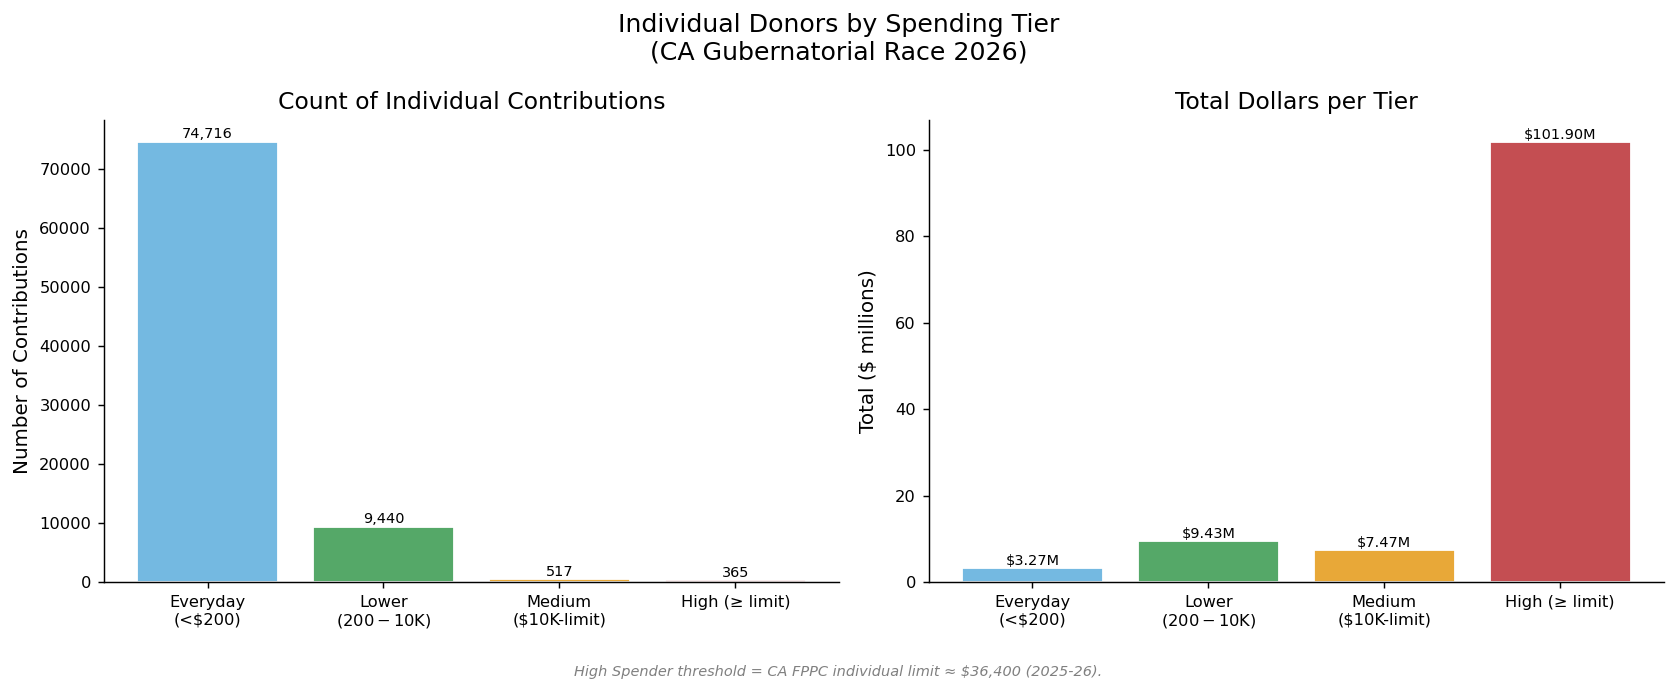

Saved: 02_individual_buckets.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Individual Donors by Spending Tier\n(CA Gubernatorial Race 2026)",
    fontsize=14,
)
x = np.arange(len(BUCKET_ORDER))
labels_wrap = [textwrap.fill(b, 14) for b in BUCKET_ORDER]

# Panel A: count
bars1 = ax1.bar(x, bucket_stats["n"], color=BUCKET_COLORS, edgecolor="white")
ax1.set_xticks(x); ax1.set_xticklabels(labels_wrap, fontsize=9)
ax1.set_ylabel("Number of Contributions")
ax1.set_title("Count of Individual Contributions")
for bar, v in zip(bars1, bucket_stats["n"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"{v:,.0f}", ha="center", va="bottom", fontsize=8)

# Panel B: total dollars
bars2 = ax2.bar(x, bucket_stats["total"]/1e6, color=BUCKET_COLORS, edgecolor="white")
ax2.set_xticks(x); ax2.set_xticklabels(labels_wrap, fontsize=9)
ax2.set_ylabel("Total ($ millions)")
ax2.set_title("Total Dollars per Tier")
for bar, v in zip(bars2, bucket_stats["total"]/1e6):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"${v:.2f}M", ha="center", va="bottom", fontsize=8)

fig.text(
    0.5, -0.04,
    f"High Spender threshold = CA FPPC individual limit ≈ ${CA_INDIVIDUAL_LIMIT:,} (2025-26).",
    ha="center", fontsize=8, style="italic", color="gray",
)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_individual_buckets.png", bbox_inches="tight")
plt.show()
print("Saved: 02_individual_buckets.png")


### 3a. Deep Dive: Who are the High Spenders?

Let's look at the top donors in the "High Spender" tier — names and amounts.


In [12]:
high = indiv[indiv["bucket"] == "High (≥ limit)"].copy()
high_summary = (
    high.groupby("_name")
    .agg(
        n_contributions=("amount_clean", "count"),
        total_donated=("amount_clean", "sum"),
        occupation=("_occ", "first"),
    )
    .sort_values("total_donated", ascending=False)
    .head(30)
)
high_summary.index.name = "Contributor Name"
display(high_summary.style.format({"total_donated": "${:,.0f}", "n_contributions": "{:,.0f}"}))


,n_contributions,total_donated,occupation
Contributor Name,,,
"Steyer, Tom",16,"$88,166,852",Candidate
"Cloobeck, Stephen",3,"$3,780,385",Candidate
"Zacky, Leo",6,"$443,000",businessman/farmer
"Slavet, Jonathan",4,"$400,000",CEO
"Ahn, Che",2,"$204,167",Pastor
"Hilton, Stephen",2,"$178,000",Owner
"Penner, Ethan",3,"$150,000",CEO
"Fardad, Farshad",2,"$78,400",Chief Executive Officer
"Tang, Stanley",2,"$78,400",Co-Founder


In [11]:
df[df["Contributor Name"] == "Safai, Bob"]

,Transaction Type,Cycle,Election,Start Date,End Date,Amount,Recipient Name,Recipient Committee,Recipient Committee ID,Office,...,Contributor Zip Code,Contributor Employer,Contributor Occupation,Candidate Contribution,Ballot Measure Contribution,Allied Committee,amount_clean,donor_type,_name,_occ
86963,Late Contribution,2025,2026-06-02,2026-02-24,2026-02-24,39200,"MAHAN, MATT",Mahan for Governor 2026,1486858,Governor,...,91302,Madison Partners,Founding Partner & Chief Executive Officer,Y,N,N,39200.0,Individual,"Safai, Bob",Founding Partner & Chief Executive Officer


## 4. OpenSecrets Name Matching

We attempt to match individual donor names against the 
**ContributionOpenSecretsCategories** database (~298K entries, each with an 
industry classification at three levels of specificity).

**Matching strategy**: case-insensitive exact match after normalising punctuation 
and whitespace. This is conservative — fuzzy matching would increase recall but 
at the cost of precision.

**Key question**: Do high-dollar donors (especially the "High Spender" tier) 
appear in OpenSecrets, indicating they are repeat political donors with known 
industry affiliations?


In [52]:
os_df = pd.read_csv(OPENSECRETS_PATH, dtype=str, low_memory=False)
os_df.columns = [c.strip() for c in os_df.columns]
os_df["name_norm"] = os_df["name"].apply(normalise_name)

print(f"OpenSecrets entries: {len(os_df):,}")
print(f"  Non-Uncoded (has industry): {(os_df['level1_category'] != 'Uncoded').sum():,}")
print()
print("Top level1 categories:")
display(os_df["level1_category"].value_counts().head(10).to_frame("count"))


OpenSecrets entries: 298,192
  Non-Uncoded (has industry): 40,813

Top level1 categories:


,count
level1_category,
Uncoded,257379
Government Agencies/Education/Other,7548
"Finance, Insurance & Real Estate",6572
Lawyers & Lobbyists,5922
Health,4112
Communications & Electronics,4055
General Business,2780
Energy & Natural Resources,1481
Construction,1478


In [53]:
# Build lookup dict: normalised name → row data
os_lookup = (
    os_df.drop_duplicates("name_norm")
    .set_index("name_norm")[["level1_category", "level2_category", "level3_category"]]
    .to_dict(orient="index")
)

# Match
indiv["name_norm"]  = indiv["_name"].apply(normalise_name)
indiv["os_matched"] = indiv["name_norm"].isin(os_lookup)
indiv["os_level1"]  = indiv["name_norm"].map({k: v["level1_category"] for k, v in os_lookup.items()})
indiv["os_level2"]  = indiv["name_norm"].map({k: v["level2_category"] for k, v in os_lookup.items()})
indiv["os_level3"]  = indiv["name_norm"].map({k: v["level3_category"] for k, v in os_lookup.items()})

print(f"Overall individual match rate: {indiv['os_matched'].mean()*100:.1f}%")


Overall individual match rate: 27.6%


In [43]:
# ── Build dataset of "uncoded" big-donor companies ────────────────────────────
# For donations ≥ $10K where the donor has NO industry classification in
# OpenSecrets (either no match at all, OR matched but tagged "Uncoded"), pull
# a company name:
#   • Individual    → Contributor Employer
#   • Organization  → Contributor Name
#   • PAC/Committee → Contributor Name
# Output: a deduped CSV of unique company names that need manual industry coding.

THRESHOLD = 10_000
col_emp = detect_col(df, ["Contributor Employer", "CTRIB_EMP"])

# Match every ≥$10K row against OpenSecrets (not just individuals, since orgs
# also need to be checked).
big = df[df["amount_clean"] >= THRESHOLD].copy()
big["name_norm"] = big["_name"].apply(normalise_name)
big["os_level1"] = big["name_norm"].map(
    {k: v["level1_category"] for k, v in os_lookup.items()}
)

# Uncoded = unmatched OR matched-but-Uncoded
uncoded_mask = big["os_level1"].isna() | big["os_level1"].eq("Uncoded")
big_uncoded = big[uncoded_mask].copy()

# Pick the "company" string per row
big_uncoded["company_raw"] = np.where(
    big_uncoded["donor_type"].eq("Individual"),
    big_uncoded[col_emp].fillna("").str.strip(),
    big_uncoded["_name"].str.strip(),
)
big_uncoded["company_raw"] = (
    big_uncoded["company_raw"]
    .replace({"": np.nan, "nan": np.nan, "NaN": np.nan})
)

# Unique companies → export
companies = (
    big_uncoded[["company_raw"]]
    .dropna()
    .drop_duplicates()
    .sort_values("company_raw")
    .rename(columns={"company_raw": "company"})
    .reset_index(drop=True)
)

out_path = OUTPUT_DIR / "uncoded_big_donor_companies.csv"
companies.to_csv(out_path, index=False)

print(f"Donations ≥ ${THRESHOLD:,}:                    {len(big):,}")
print(f"  …of which uncoded (no industry):          {len(big_uncoded):,}")
print(f"  …of which have a non-blank company name:  {big_uncoded['company_raw'].notna().sum():,}")
print(f"Unique companies exported:                  {len(companies):,}")
print(f"Saved: {out_path}")
display(companies.head(20))


Donations ≥ $10,000:                    1,029
  …of which uncoded (no industry):          913
  …of which have a non-blank company name:  854
Unique companies exported:                  606
Saved: /Users/kateli/Desktop/CalMatters/campaign finance categorization/data/02_output/uncoded_big_donor_companies.csv


,company
0,128 Collective
1,1P Advocacy
2,21st Century Alliance - Silicon Valley Chapter
3,"450 Attorneys, Inc"
4,7X
5,8vc
6,@Properties and Christie's International Real ...
7,@properties
8,AMERICAN RESORT DEVELOPMENT ASSOCIATION RESORT...
9,"AMR HOLDCO, Inc."


In [44]:
# ── Sanity check: per-company donation counts should sum to total ─────────────
# Each row of `big_uncoded` is one donation. Group by company and confirm that
# the sum across companies equals the total uncoded ≥ $10K rows.

per_company = (
    big_uncoded
    .assign(company=big_uncoded["company_raw"].fillna("(blank / missing)"))
    .groupby("company")
    .agg(
        n_donations=("amount_clean", "size"),
        total_dollars=("amount_clean", "sum"),
    )
    .sort_values("n_donations", ascending=False)
)

print(f"Total uncoded ≥ ${THRESHOLD:,} donations:    {len(big_uncoded):,}")
print(f"Sum of n_donations across companies:         {int(per_company['n_donations'].sum()):,}")
print(f"Distinct company strings (incl. blank):      {len(per_company):,}")
print(f"Total dollar volume:                         ${per_company['total_dollars'].sum():,.0f}")
print()
print("Donor-type breakdown of the filtered set:")
display(big_uncoded["donor_type"].value_counts().to_frame("n_donations"))
print()
print("Top 20 companies by donation count:")
display(
    per_company.head(20).style.format(
        {"n_donations": "{:,.0f}", "total_dollars": "${:,.0f}"}
    )
)


Total uncoded ≥ $10,000 donations:    913
Sum of n_donations across companies:         913
Distinct company strings (incl. blank):      607
Total dollar volume:                         $122,988,442

Donor-type breakdown of the filtered set:


,n_donations
donor_type,
Individual,668
Organization,141
PAC/Committee,104



Top 20 companies by donation count:


,n_donations,total_dollars
company,,
(blank / missing),59,"$1,562,400"
Retired,42,"$876,200"
Not Employed,36,"$696,400"
Steyer for Governor 2026,25,"$88,317,341"
Unitemized Contributions,16,"$3,877,786"
Harvest Rock Church,13,"$353,753"
Y Combinator,9,"$266,800"
none,7,"$453,000"
Thunder Parley,6,"$81,234"


### 4a. Match Rate by Spending Tier

In [54]:
match_rows = []
for b in BUCKET_ORDER:
    sub = indiv[indiv["bucket"] == b]
    total    = len(sub)
    matched  = sub["os_matched"].sum()
    with_ind = (sub["os_matched"] & sub["os_level1"].ne("Uncoded")).sum()
    match_rows.append({
        "Tier":                     b,
        "N Contributions":          total,
        "In OpenSecrets":           int(matched),
        "Match Rate":               f"{matched/total*100:.1f}%" if total else "—",
        "Has Industry (non-Uncoded)": int(with_ind),
        "Industry Match Rate":      f"{with_ind/total*100:.1f}%" if total else "—",
    })

match_table = pd.DataFrame(match_rows).set_index("Tier")
display(match_table)


,N Contributions,In OpenSecrets,Match Rate,Has Industry (non-Uncoded),Industry Match Rate
Tier,,,,,
Everyday (<$200),76773,19517,25.4%,3560,4.6%
Lower ($200-$10K),9509,4182,44.0%,1176,12.4%
Medium ($10K-limit),521,273,52.4%,80,15.4%
High (≥ limit),478,153,32.0%,47,9.8%


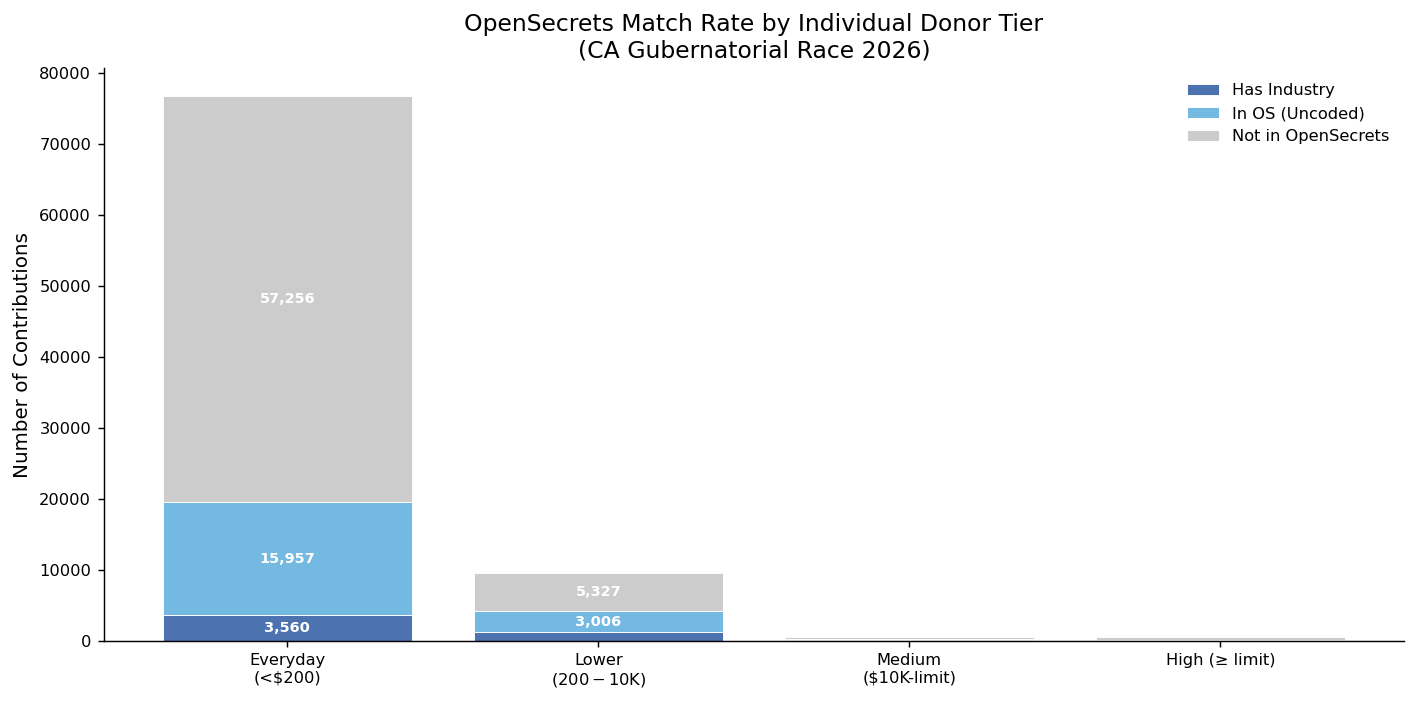

Saved: 03_opensecrets_match_rates.png


In [57]:
fig, ax = plt.subplots(figsize=(11, 5.5))

stack_data = []
for b in BUCKET_ORDER:
    sub = indiv[indiv["bucket"] == b]
    n = len(sub)
    has_ind  = (sub["os_matched"] & sub["os_level1"].ne("Uncoded")).sum()
    has_unc  = (sub["os_matched"] & sub["os_level1"].eq("Uncoded")).sum()
    no_match = (~sub["os_matched"]).sum()
    stack_data.append({"Has Industry": has_ind, "In OS (Uncoded)": has_unc,
                        "Not in OpenSecrets": no_match, "total": n})

stack_df = pd.DataFrame(stack_data, index=BUCKET_ORDER)
stack_colors = ["#4C72B0", "#74B9E1", "#CCCCCC"]
cols = ["Has Industry", "In OS (Uncoded)", "Not in OpenSecrets"]

bottom = np.zeros(len(BUCKET_ORDER))
for col, color in zip(cols, stack_colors):
    vals = stack_df[col].values.astype(float)
    bars = ax.bar(BUCKET_ORDER, vals, bottom=bottom, color=color,
                  edgecolor="white", linewidth=0.5, label=col)
    for bar, v in zip(bars, vals):
        if v > stack_df["total"].max() * 0.025:
            yc = bar.get_y() + bar.get_height() / 2
            ax.text(bar.get_x() + bar.get_width()/2, yc, f"{int(v):,}",
                    ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    bottom += vals

ax.set_xticks(range(len(BUCKET_ORDER)))
ax.set_xticklabels([textwrap.fill(b, 14) for b in BUCKET_ORDER], fontsize=9)
ax.set_ylabel("Number of Contributions")
ax.set_title(
    "OpenSecrets Match Rate by Individual Donor Tier\n"
    "(CA Gubernatorial Race 2026)", fontsize=13,
)
ax.legend(loc="upper right", frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "03_opensecrets_match_rates.png", bbox_inches="tight")
plt.show()
print("Saved: 03_opensecrets_match_rates.png")


### 4b. Industry Sector Breakdown (Matched Donors with Known Industry)

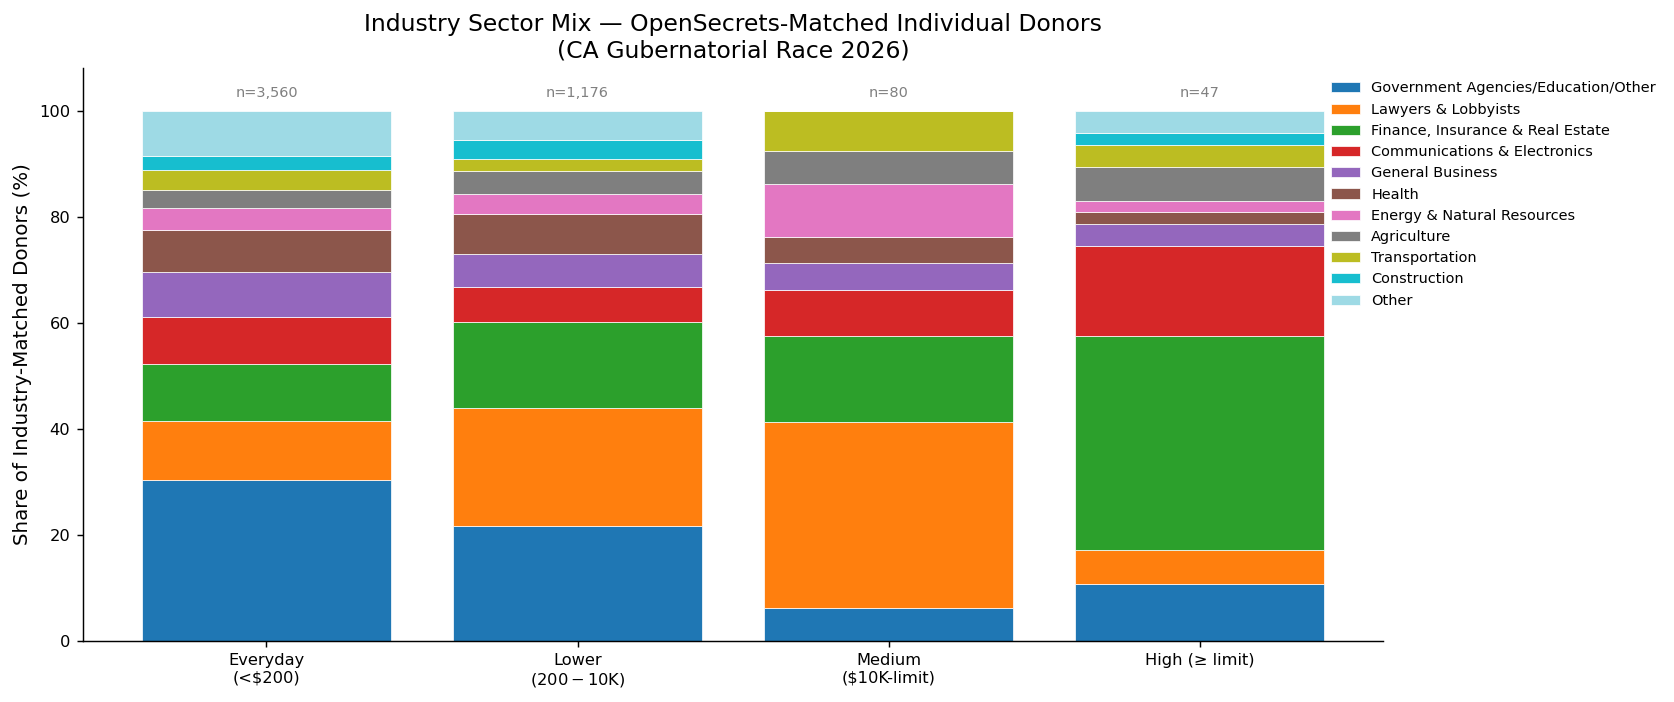

Saved: 04_matched_industry_by_bucket.png


In [58]:
matched_ind = indiv[indiv["os_matched"] & indiv["os_level1"].ne("Uncoded")].copy()

if matched_ind.empty:
    print("No donors with confirmed industry classifications — check match quality above.")
else:
    pivot = (
        matched_ind.groupby(["bucket", "os_level1"])
        .size()
        .unstack(fill_value=0)
        .reindex(BUCKET_ORDER)
        .fillna(0)
    )

    # Keep top 10 sectors + collapse rest to "Other"
    TOP_N = 10
    top_sectors = pivot.sum().nlargest(TOP_N).index.tolist()
    other_col = pivot.drop(columns=top_sectors, errors="ignore").sum(axis=1)
    pivot = pivot[top_sectors].copy()
    if (other_col > 0).any():
        pivot["Other"] = other_col
        top_sectors.append("Other")

    # As % share within each bucket
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).fillna(0) * 100

    fig, ax = plt.subplots(figsize=(13, 5.5))
    cmap = plt.get_cmap("tab20", len(top_sectors))
    bottom = np.zeros(len(BUCKET_ORDER))

    for i, col in enumerate(top_sectors):
        vals = pivot_pct[col].values if col in pivot_pct.columns else np.zeros(len(BUCKET_ORDER))
        ax.bar(BUCKET_ORDER, vals, bottom=bottom, color=cmap(i),
               edgecolor="white", linewidth=0.4, label=col)
        bottom += vals

    count_per_bucket = matched_ind.groupby("bucket").size().reindex(BUCKET_ORDER).fillna(0)
    for i, b in enumerate(BUCKET_ORDER):
        n = int(count_per_bucket[b])
        ax.text(i, 102, f"n={n:,}", ha="center", va="bottom", fontsize=8, color="gray")

    ax.set_xticks(range(len(BUCKET_ORDER)))
    ax.set_xticklabels([textwrap.fill(b, 14) for b in BUCKET_ORDER], fontsize=9)
    ax.set_ylim(0, 108)
    ax.set_ylabel("Share of Industry-Matched Donors (%)")
    ax.set_title(
        "Industry Sector Mix — OpenSecrets-Matched Individual Donors\n"
        "(CA Gubernatorial Race 2026)", fontsize=13,
    )
    ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1), frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    fig.savefig(FIG_DIR / "04_matched_industry_by_bucket.png", bbox_inches="tight")
    plt.show()
    print("Saved: 04_matched_industry_by_bucket.png")


### 4c. High Spenders — Detailed Industry View

For the "High Spender" tier specifically, let's see the level-2 and level-3 
industry breakdowns (more granular than the sector view above).


In [59]:
high_matched = indiv[
    (indiv["bucket"] == "High (≥ limit)")
    & indiv["os_matched"]
    & indiv["os_level1"].ne("Uncoded")
].copy()

print(f"High Spenders with confirmed industry: {len(high_matched):,}")

if not high_matched.empty:
    print("\n── Level 1 (Sector) ──")
    display(high_matched["os_level1"].value_counts().head(15).to_frame("count"))
    print("\n── Level 2 (Sub-sector) ──")
    display(high_matched["os_level2"].value_counts().head(15).to_frame("count"))
    print("\n── Level 3 (Specific industry) ──")
    display(high_matched["os_level3"].value_counts().head(15).to_frame("count"))


High Spenders with confirmed industry: 47

── Level 1 (Sector) ──


,count
os_level1,
"Finance, Insurance & Real Estate",19
Communications & Electronics,8
Government Agencies/Education/Other,5
Lawyers & Lobbyists,3
Agriculture,3
General Business,2
Labor,2
Transportation,2
Energy & Natural Resources,1



── Level 2 (Sub-sector) ──


,count
os_level2,
Real Estate,11
Computer Equipment & Services,7
Securities & Investment,6
Education,5
Lawyers & Lobbyists,3
General Trade Unions,2
Food Processing & Sales,2
Automotive,2
Miscellaneous Services,1



── Level 3 (Specific industry) ──


,count
os_level3,
Real estate agents & managers,8
Internet & Online Services,7
Attorneys & law firms,3
Schools & colleges,3
"Securities, commodities & investment",3
Venture capital,3
Construction unions,2
Food stores,2
Truck & automotive parts and accessories,2


## 5. Save Summary CSV

In [60]:
rows = []
for b in BUCKET_ORDER:
    sub = indiv[indiv["bucket"] == b]
    n    = len(sub)
    tot  = sub["amount_clean"].sum()
    mat  = sub["os_matched"].sum()
    ind  = (sub["os_matched"] & sub["os_level1"].ne("Uncoded")).sum()
    rows.append({
        "bucket":                  b,
        "n_contributions":         n,
        "total_amount_usd":        round(tot, 2),
        "n_matched_opensecrets":   int(mat),
        "pct_matched":             round(mat / n * 100, 2) if n else 0,
        "n_with_industry":         int(ind),
        "pct_with_industry":       round(ind / n * 100, 2) if n else 0,
    })

summary_csv = pd.DataFrame(rows)
out_path = OUTPUT_DIR / "opensecrets_match_summary.csv"
summary_csv.to_csv(out_path, index=False)
print("Saved:", out_path)
display(summary_csv)


Saved: /Users/kateli/Desktop/CalMatters/campaign finance categorization/data/02_output/opensecrets_match_summary.csv


,bucket,n_contributions,total_amount_usd,n_matched_opensecrets,pct_matched,n_with_industry,pct_with_industry
0,Everyday (<$200),76773,3.327924e+06,19517,25.42,3560,4.64
1,Lower ($200-$10K),9509,9.492720e+06,4182,43.98,1176,12.37
2,Medium ($10K-limit),521,7.514984e+06,273,52.40,80,15.36
3,High (≥ limit),478,1.051539e+08,153,32.01,47,9.83


## 6. Interpretation & Key Takeaways

Run the cells above first, then fill in the numbers below.

**Hypothesis**: High-dollar individual donors ($36,400+) are more likely to be 
repeat political donors who appear in OpenSecrets, and can therefore be assigned 
an industry classification.

**What to look for**:
- **Match rate vs. spending tier**: Does the match rate increase as donation size grows?
- **Industry of high spenders**: Are certain sectors (Finance, Real Estate, Lawyers, 
  Energy) disproportionately represented in the high-spend tier vs. the everyday tier?
- **Volume vs. value**: The "Everyday" tier likely contains the most *donors*, 
  but the "High Spender" and "Medium Spender" tiers likely contribute the bulk 
  of *total dollars*.

---
*Script version of this notebook: `02_donation_analysis.py`  
Output figures: `data/02_output/figures/`*


## 7. Donor Mix by Spending Tier — Top 10 Candidates

For each of the **top 10 candidates** (by total dollars raised), a pie chart shows
what share of their fundraising came from each donor type / spending tier:

| Slice | Meaning |
|---|---|
| **High (≥ limit)** | Individual donors at or above the FPPC limit (~$36,400) |
| **Medium ($10K–limit)** | Individual donors between $10K and the limit |
| **Lower ($200–$10K)** | Individual donors between $200 and $10K |
| **Everyday (<$200)** | Individual donors below $200 |
| **Organization** | Entities with no Contributor ID and no occupation |
| **PAC/Committee** | Entities with a Contributor ID |


In [61]:
# ── Detect the filer / candidate column ───────────────────────────────────────
col_filer = detect_col(df, [
    "Filer_NamL", "Filer Name", "FILER_NAML", "Committee Name",
    "Recipient Name", "Candidate Name", "filer_name", "committee_name",
    "Payee Name",
])
if col_filer is None:
    # Fallback: grab the first column whose name contains a relevant keyword
    for c in df.columns:
        if any(kw in c.lower() for kw in ["filer", "committee", "recipient", "candidate"]):
            col_filer = c
            break

print(f"Filer/candidate column detected: {col_filer!r}")
print("\nTop 15 filer names by row count:")
display(df[col_filer].value_counts().head(15).to_frame("# rows"))


Filer/candidate column detected: 'Recipient Name'

Top 15 filer names by row count:


,# rows
Recipient Name,
"PORTER, KATIE",48621
"HILTON, STEVE",17994
"BIANCO, CHAD",10416
"BECERRA, XAVIER",2865
"YEE , BETTY T.",2131
"SWALWELL, ERIC M.",1854
"ATKINS, TONI G.",1399
"VILLARAIGOSA, ANTONIO",1008
"WARE, RUDOLPH ""BUTCH"" T",707


In [62]:
# ── Build a unified tier/type label on the full dataframe ─────────────────────
# Individuals → spending tier bucket
# Organizations / PACs → their donor_type string

def _tier_label(row):
    if row["donor_type"] == "Individual":
        amt = row["amount_clean"]
        if pd.isna(amt):
            return "Everyday (<$200)"
        for label, (lo, hi) in BUCKET_LIMITS.items():
            if lo <= amt < hi:
                return label
        return BUCKET_ORDER[-1]          # catch-all for very large amounts
    return row["donor_type"]             # "Organization" or "PAC/Committee"

df["tier_label"] = df.apply(_tier_label, axis=1)

# ── Top 10 candidates by total dollars raised ──────────────────────────────────
top10_names = (
    df.groupby(col_filer)["amount_clean"]
    .sum()
    .nlargest(10)
    .index
    .tolist()
)

print("Top 10 candidates:")
top10_totals = (
    df[df[col_filer].isin(top10_names)]
    .groupby(col_filer)["amount_clean"]
    .sum()
    .loc[top10_names]
)
display(
    top10_totals
    .rename("Total Raised ($)")
    .map("${:,.0f}".format)
    .to_frame()
)


Top 10 candidates:


,Total Raised ($)
Recipient Name,
"STEYER, THOMAS F.","$88,513,819"
"MAHAN, MATT","$10,831,444"
"HILTON, STEVE","$6,288,745"
"PORTER, KATIE","$5,847,166"
"SWALWELL, ERIC M.","$5,834,474"
"BIANCO, CHAD","$4,066,122"
"CLOOBECK, STEPHEN J.","$3,990,981"
"VILLARAIGOSA, ANTONIO","$3,614,038"
"BECERRA, XAVIER","$2,855,151"


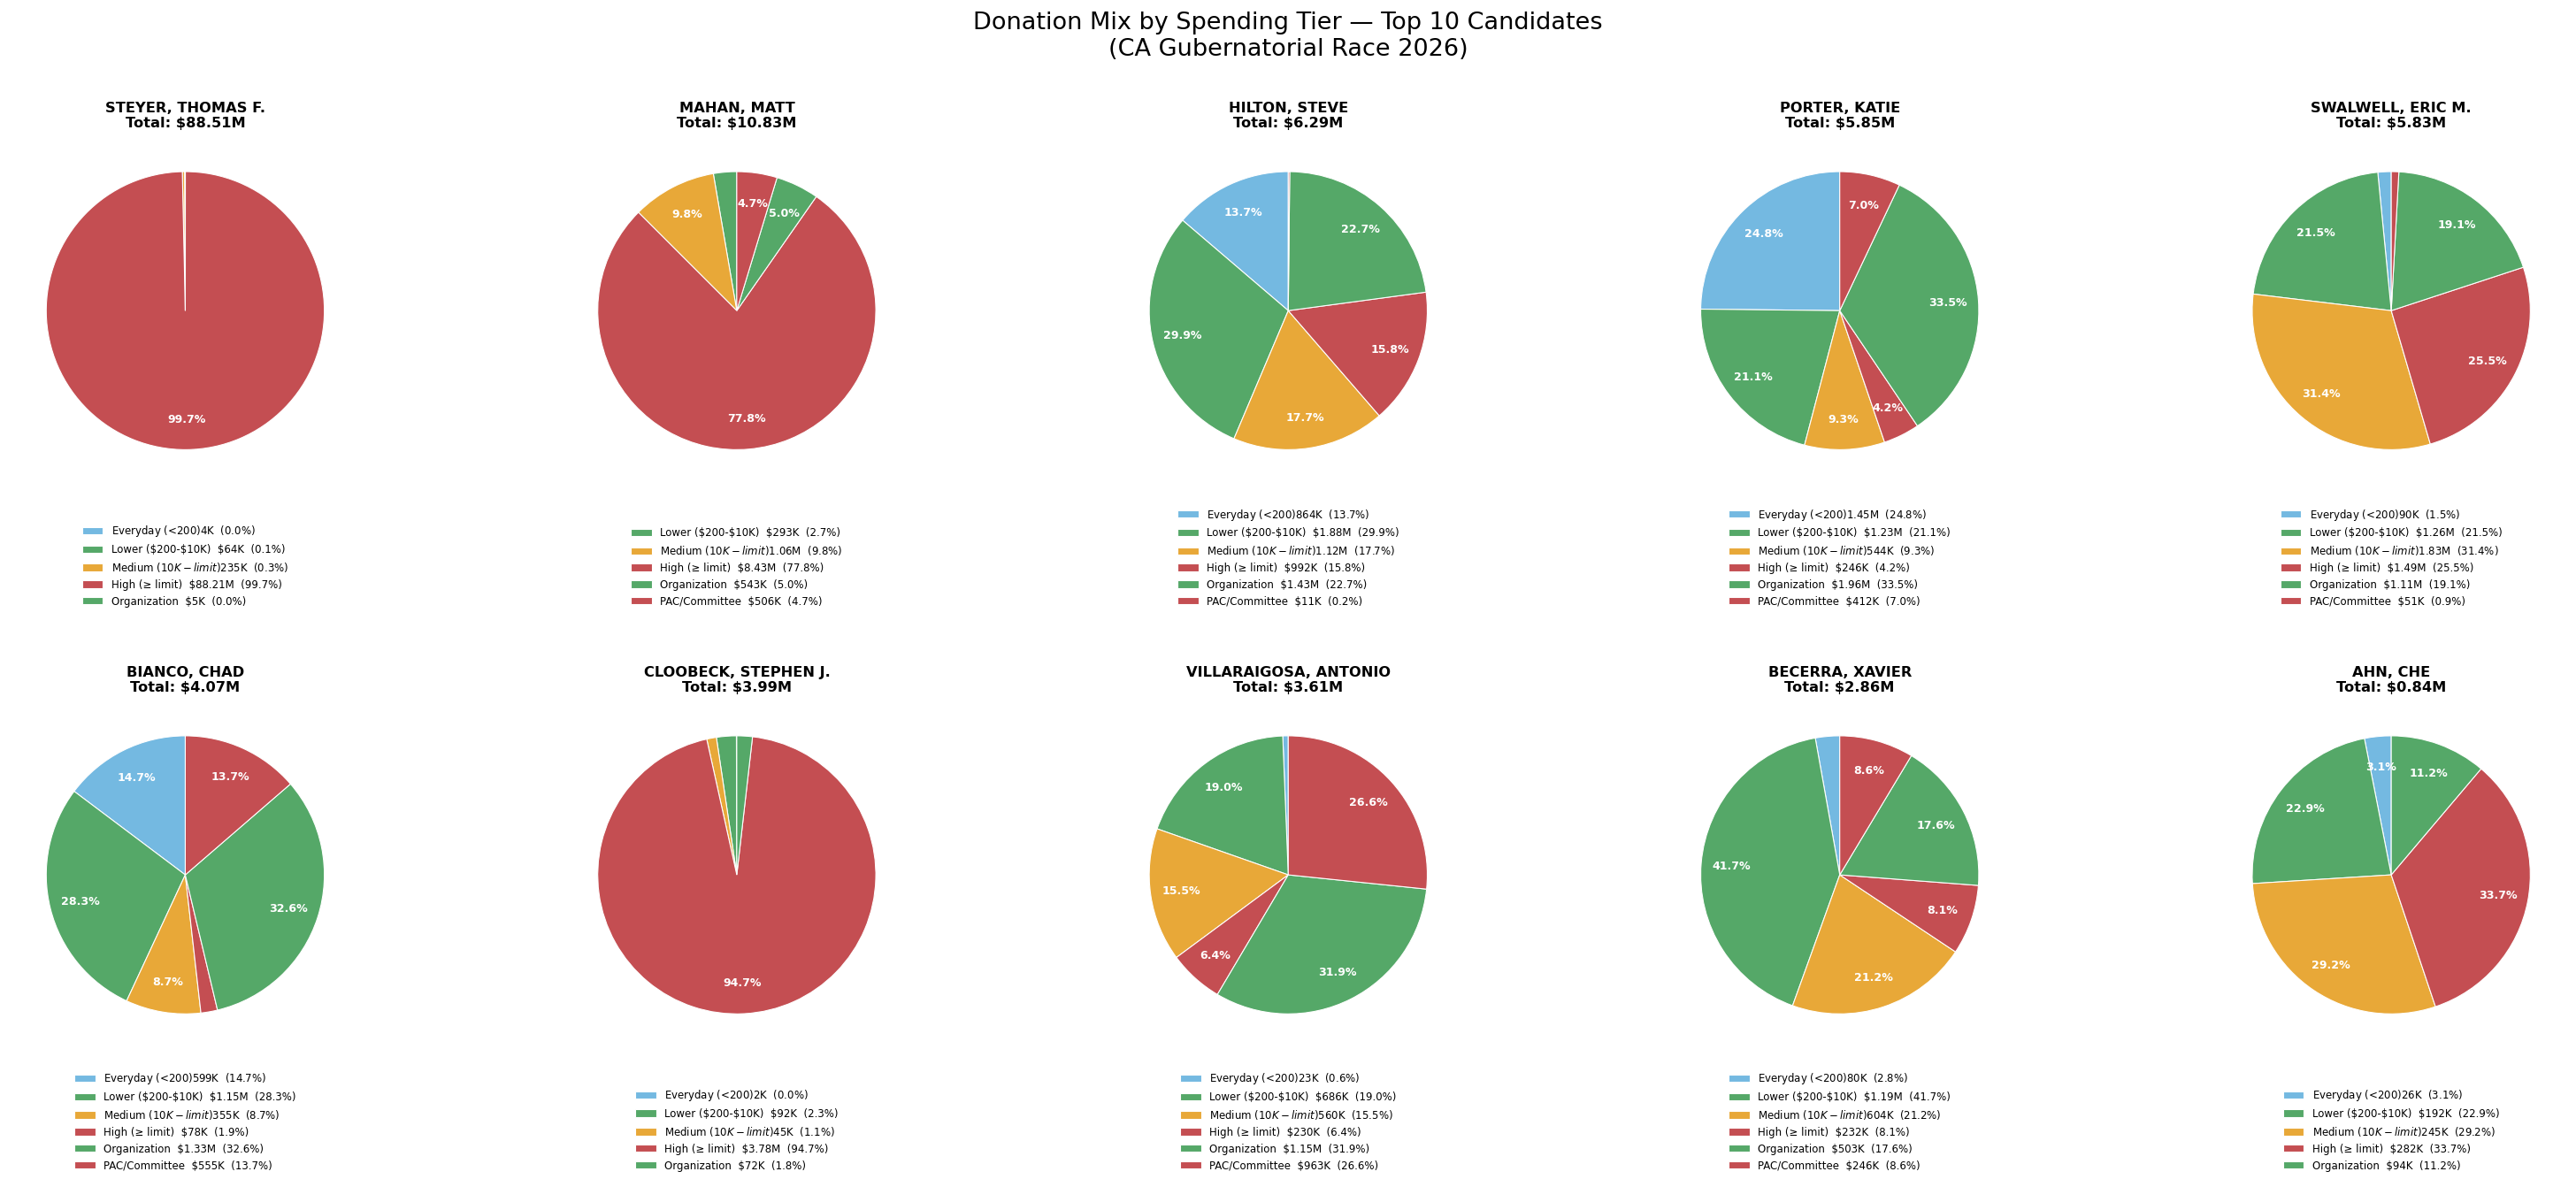

Saved: 07_top10_donor_tier_pies.png


In [63]:
# ── Pie charts: dollar share by tier/type for each top-10 candidate ───────────
TIER_ORDER  = BUCKET_ORDER + ["Organization", "PAC/Committee"]
TIER_COLORS = BUCKET_COLORS + [DONOR_COLORS["Organization"], DONOR_COLORS["PAC/Committee"]]
TIER_COLOR_MAP = dict(zip(TIER_ORDER, TIER_COLORS))

# 2 rows × 5 columns
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle(
    "Donation Mix by Spending Tier — Top 10 Candidates\n(CA Gubernatorial Race 2026)",
    fontsize=15, y=1.02,
)

for ax, cand in zip(axes.flatten(), top10_names):
    sub   = df[df[col_filer] == cand]
    total = sub["amount_clean"].sum()

    # Dollar amount per tier (present tiers only, in defined order)
    tier_totals = (
        sub.groupby("tier_label")["amount_clean"]
        .sum()
        .reindex(TIER_ORDER)
        .fillna(0)
    )
    active = tier_totals[tier_totals > 0]

    sizes  = active.values
    colors = [TIER_COLOR_MAP[t] for t in active.index]

    # Custom autopct: show pct only for slices ≥ 3 %
    def make_autopct(vals):
        def _autopct(pct):
            return f"{pct:.1f}%" if pct >= 3 else ""
        return _autopct

    wedges, texts, autotexts = ax.pie(
        sizes,
        colors=colors,
        startangle=90,
        autopct=make_autopct(sizes),
        pctdistance=0.78,
        wedgeprops={"linewidth": 0.6, "edgecolor": "white"},
        textprops={"fontsize": 7.5},
    )
    for at in autotexts:
        at.set_fontsize(7)
        at.set_color("white")
        at.set_fontweight("bold")

    # Legend with tier name + dollar amount + pct
    legend_labels = [
        f"{t}  ${v/1e6:.2f}M  ({v/total*100:.1f}%)"
        if v >= 1e6
        else f"{t}  ${v/1e3:.0f}K  ({v/total*100:.1f}%)"
        for t, v in zip(active.index, active.values)
    ]
    ax.legend(
        wedges, legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.38),
        fontsize=6.5,
        frameon=False,
        ncol=1,
    )

    cand_short = textwrap.fill(cand, 28)
    ax.set_title(
        f"{cand_short}\nTotal: ${total/1e6:.2f}M",
        fontsize=9, fontweight="bold", pad=6,
    )

fig.tight_layout(h_pad=5, w_pad=2)
fig.savefig(FIG_DIR / "07_top10_donor_tier_pies.png", bbox_inches="tight")
plt.show()
print("Saved: 07_top10_donor_tier_pies.png")


## 8. Fundraising by Spending Tier Only — Top 10 Candidates

Same as Section 7, but **all contributions** (individuals, organizations, and PACs/committees)
are bucketed purely by donation amount into the four spending tiers.
Donor type is ignored — a $50,000 PAC contribution falls in the "High" tier just
like a $50,000 individual donation.

| Tier | Range |
|---|---|
| **High (≥ limit)** | ≥ $36,400 |
| **Medium ($10K–limit)** | $10,000 – $36,400 |
| **Lower ($200–$10K)** | $200 – $10,000 |
| **Everyday (<$200)** | < $200 |

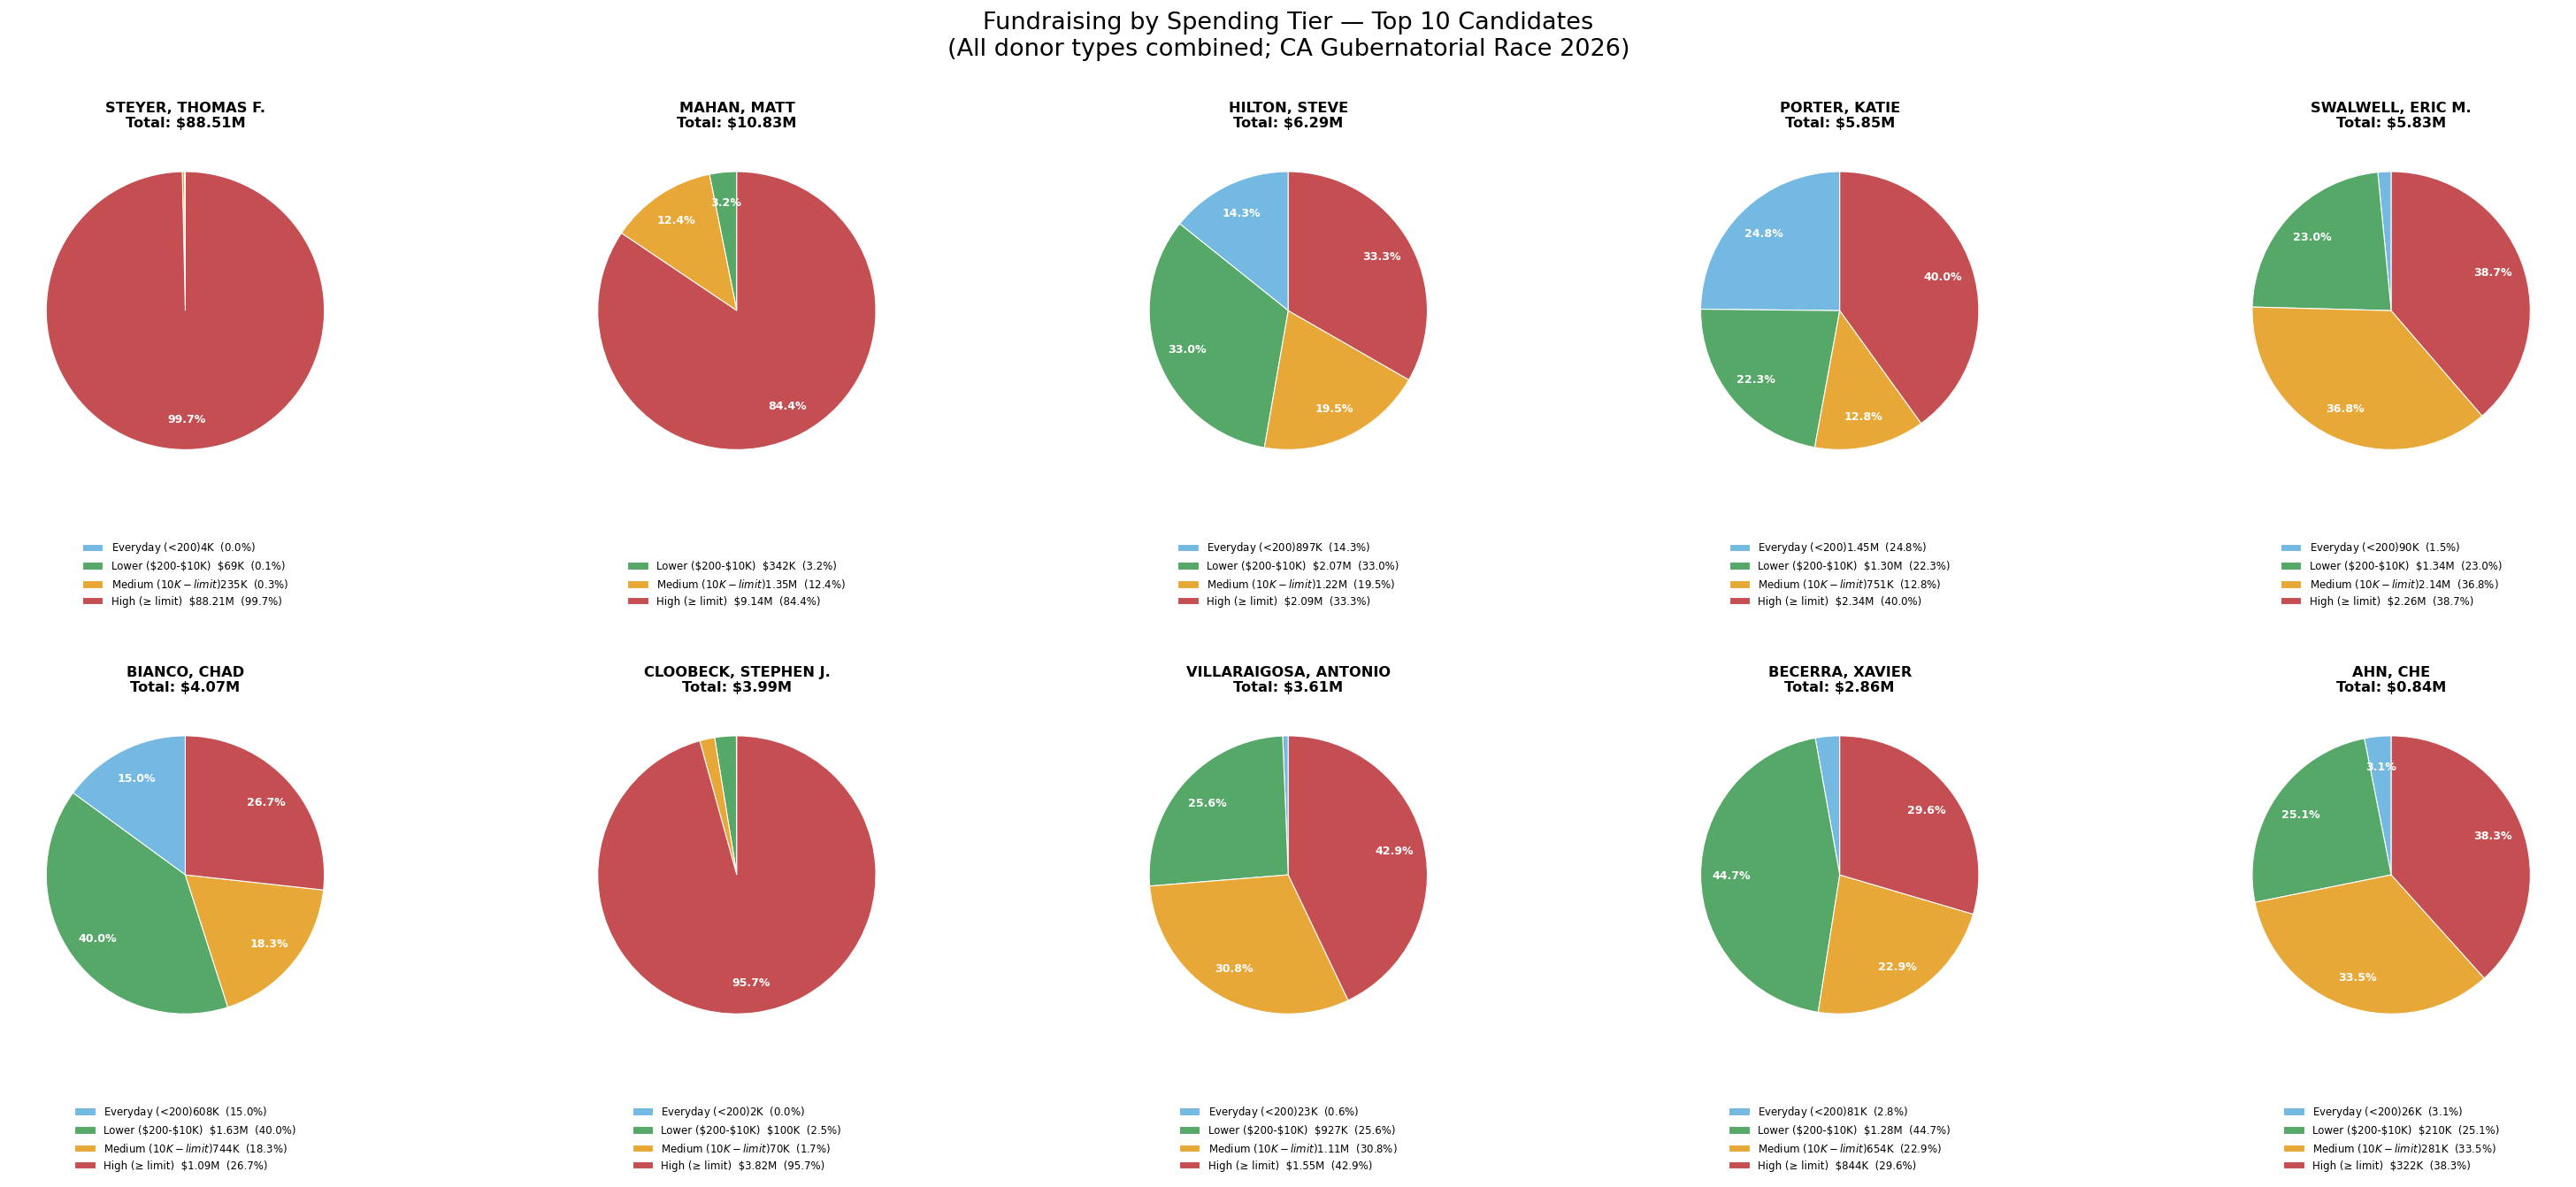

Saved: 08_top10_spending_tier_pies.png


In [64]:
# ── Assign every contribution a spending tier based purely on amount ───────────
def assign_bucket_universal(amt):
    if pd.isna(amt):
        return "Everyday (<$200)"
    for label, (lo, hi) in BUCKET_LIMITS.items():
        if lo <= amt < hi:
            return label
    return BUCKET_ORDER[-1]

df["tier_label_unified"] = df["amount_clean"].apply(assign_bucket_universal)

# ── Pie charts: dollar share by spending tier for each top-10 candidate ────────
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle(
    "Fundraising by Spending Tier — Top 10 Candidates\n"
    "(All donor types combined; CA Gubernatorial Race 2026)",
    fontsize=15, y=1.02,
)

for ax, cand in zip(axes.flatten(), top10_names):
    sub   = df[df[col_filer] == cand]
    total = sub["amount_clean"].sum()

    tier_totals = (
        sub.groupby("tier_label_unified")["amount_clean"]
        .sum()
        .reindex(BUCKET_ORDER)
        .fillna(0)
    )
    active = tier_totals[tier_totals > 0]

    sizes  = active.values
    colors = [dict(zip(BUCKET_ORDER, BUCKET_COLORS))[t] for t in active.index]

    def make_autopct(vals):
        def _autopct(pct):
            return f"{pct:.1f}%" if pct >= 3 else ""
        return _autopct

    wedges, texts, autotexts = ax.pie(
        sizes,
        colors=colors,
        startangle=90,
        autopct=make_autopct(sizes),
        pctdistance=0.78,
        wedgeprops={"linewidth": 0.6, "edgecolor": "white"},
        textprops={"fontsize": 7.5},
    )
    for at in autotexts:
        at.set_fontsize(7)
        at.set_color("white")
        at.set_fontweight("bold")

    legend_labels = [
        f"{t}  ${v/1e6:.2f}M  ({v/total*100:.1f}%)"
        if v >= 1e6
        else f"{t}  ${v/1e3:.0f}K  ({v/total*100:.1f}%)"
        for t, v in zip(active.index, active.values)
    ]
    ax.legend(
        wedges, legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.38),
        fontsize=6.5,
        frameon=False,
        ncol=1,
    )

    cand_short = textwrap.fill(cand, 28)
    ax.set_title(
        f"{cand_short}\nTotal: ${total/1e6:.2f}M",
        fontsize=9, fontweight="bold", pad=6,
    )

fig.tight_layout(h_pad=5, w_pad=2)
fig.savefig(FIG_DIR / "08_top10_spending_tier_pies.png", bbox_inches="tight")
plt.show()
print("Saved: 08_top10_spending_tier_pies.png")